<a href="https://colab.research.google.com/github/Aarshi1508/ASR-transcrption-bias-on-NlP-tasks/blob/main/Stance%20classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download NLTK resources (run once)
try:
    nltk.download('punkt')
    nltk.download('stopwords')
    nltk.download('wordnet')
except:
    pass

# Load the data
url = "https://docs.google.com/spreadsheets/d/11b7e1WbVFfN6O3nOR7EhHIbM7OTTY1O5IERVFHLFbd4/export?format=csv&gid=555652084"
df = pd.read_csv(url)

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())
print("\nBasic info:")
print(df.info())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


Dataset shape: (846, 25)

First few rows:
               name                   file  \
0        Aaron Huey        AaronHuey_2010X   
1      Abha Dawesar      AbhaDawesar_2013G   
2     Abigail Marsh     AbigailMarsh_2016T   
3  Abraham Verghese  AbrahamVerghese_2011G   
4  Achenyo Idachaba  AchenyoIdachaba_2015W   

                                          transcript  text_length   age  \
0  i m here today to show my photographs of the l...         2211  35.0   
1  i was in new york during hurricane sandy and t...         1988  39.0   
2  there s a man out there somewhere who looks a ...         2044  40.0   
3  a few months ago a forty year old woman came t...         3084  56.0   
4  welcome to bayeku a riverine community in ikor...          943  45.0   

   gender   race language    wps  readability  ...   WX_WER   ZM_WER   BJ_WER  \
0    male  white       us  2.380         7.35  ...  0.12489  0.06700  0.06335   
1  female  asian       l2  2.753         6.98  ...  0.05989  0.04680

In [ ]:
# RUN THIS CODE FIRST to explore your dataset
import pandas as pd

# Load the data
url = "https://docs.google.com/spreadsheets/d/11b7e1WbVFfN6O3nOR7EhHIbM7OTTY1O5IERVFHLFbd4/export?format=csv&gid=555652084"
df = pd.read_csv(url)

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)

# Let's look at all columns and their sample content
print("\n" + "="*60)
print("EXPLORING ALL COLUMNS:")
print("="*60)
for col in df.columns:
    print(f"\n--- {col} ---")
    print(f"Data type: {df[col].dtype}")
    print(f"Non-null values: {df[col].count()}/{len(df)}")
    print(f"Sample values:")
    print(df[col].head(3).tolist())

Dataset shape: (846, 25)

Column names:
['name', 'file', 'transcript', 'text_length', 'age', 'gender', 'race', 'language', 'wps', 'readability', 'f0mean', 'YT_WER', 'FB_WER', 'MS_WER', 'GM_WER', 'WX_WER', 'ZM_WER', 'BJ_WER', 'GM', 'YT', 'MS', 'FB', 'ZM', 'BJ', 'WX']

First few rows:
               name                   file  \
0        Aaron Huey        AaronHuey_2010X   
1      Abha Dawesar      AbhaDawesar_2013G   
2     Abigail Marsh     AbigailMarsh_2016T   
3  Abraham Verghese  AbrahamVerghese_2011G   
4  Achenyo Idachaba  AchenyoIdachaba_2015W   

                                          transcript  text_length   age  \
0  i m here today to show my photographs of the l...         2211  35.0   
1  i was in new york during hurricane sandy and t...         1988  39.0   
2  there s a man out there somewhere who looks a ...         2044  40.0   
3  a few months ago a forty year old woman came t...         3084  56.0   
4  welcome to bayeku a riverine community in ikor...          94

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import re
from transformers import pipeline
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Load the data
url = "https://docs.google.com/spreadsheets/d/11b7e1WbVFfN6O3nOR7EhHIbM7OTTY1O5IERVFHLFbd4/export?format=csv&gid=555652084"
df = pd.read_csv(url)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Text columns to analyze (manual transcript + ASR versions)
text_columns = ['transcript', 'GM', 'YT', 'MS', 'FB', 'ZM', 'BJ', 'WX']
print(f"\nText columns to analyze: {text_columns}")

Dataset loaded successfully!
Shape: (846, 25)
Columns: ['name', 'file', 'transcript', 'text_length', 'age', 'gender', 'race', 'language', 'wps', 'readability', 'f0mean', 'YT_WER', 'FB_WER', 'MS_WER', 'GM_WER', 'WX_WER', 'ZM_WER', 'BJ_WER', 'GM', 'YT', 'MS', 'FB', 'ZM', 'BJ', 'WX']

Text columns to analyze: ['transcript', 'GM', 'YT', 'MS', 'FB', 'ZM', 'BJ', 'WX']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
import re
import warnings
warnings.filterwarnings('ignore')

# Load the data
url = "https://docs.google.com/spreadsheets/d/11b7e1WbVFfN6O3nOR7EhHIbM7OTTY1O5IERVFHLFbd4/export?format=csv&gid=555652084"
df = pd.read_csv(url)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

# OPTIMIZATION 1: Use smaller sample for faster testing
SAMPLE_SIZE = 30  # Start small, can increase later
df_sample = df.head(SAMPLE_SIZE).copy()

# OPTIMIZATION 2: Use only key ASR platforms for comparison
key_asr_platforms = ['GM', 'YT', 'MS', 'FB']  # Most common platforms
text_columns = ['transcript'] + key_asr_platforms
print(f"Analyzing platforms: {text_columns}")

# OPTIMIZATION 3: Use faster, smaller model
print("Loading optimized stance detection model...")
try:
    # Use smaller, faster model
    classifier = pipeline(
        "zero-shot-classification",
        model="typeform/distilbert-base-uncased-mnli",  # Much faster than BART-large
        device=-1,  # Use CPU for stability
        batch_size=8  # Process multiple texts at once
    )
    print("Fast stance detection model loaded successfully!")
except Exception as e:
    print(f"Error: {e}. Using sentiment analysis as fallback.")
    classifier = pipeline("sentiment-analysis")

# OPTIMIZATION 4: Batch processing function
def detect_stance_batch(texts):
    """Process multiple texts in batch for efficiency"""
    if not texts:
        return [("neutral", 0.0)] * len(texts)

    valid_texts = []
    original_indices = []

    # Filter out invalid texts
    for i, text in enumerate(texts):
        if pd.notna(text) and len(str(text).strip()) > 50:
            valid_texts.append(str(text)[:512])  # OPTIMIZATION: Limit text length
            original_indices.append(i)

    if not valid_texts:
        return [("neutral", 0.0)] * len(texts)

    try:
        # Batch processing
        stance_candidates = ["support", "oppose", "neutral"]
        results = classifier(valid_texts, stance_candidates)

        # Reconstruct full results
        full_results = [("neutral", 0.0)] * len(texts)
        for idx, result in zip(original_indices, results):
            full_results[idx] = (result['labels'][0], result['scores'][0])

        return full_results
    except Exception as e:
        print(f"Batch processing failed: {e}")
        return [("neutral", 0.5)] * len(texts)

# OPTIMIZATION 5: Process by column instead of by row
print(f"\nProcessing {SAMPLE_SIZE} talks across {len(text_columns)} text versions...")

# Collect all texts for batch processing
all_texts = {}
for col in text_columns:
    if col in df_sample.columns:
        all_texts[col] = df_sample[col].fillna('').tolist()

# Batch process each column
stance_results = {}
confidence_results = {}

for col, texts in all_texts.items():
    print(f"Processing {col}...")
    results = detect_stance_batch(texts)
    stances = [r[0] for r in results]
    confidences = [r[1] for r in results]

    stance_results[col] = stances
    confidence_results[col] = confidences

# Create analysis dataframe
analysis_data = []
for idx in range(SAMPLE_SIZE):
    row_data = {
        'index': idx,
        'name': df_sample.iloc[idx]['name'] if 'name' in df_sample.columns else f"Talk_{idx}",
        'gender': df_sample.iloc[idx].get('gender', 'unknown'),
        'race': df_sample.iloc[idx].get('race', 'unknown'),
        'language': df_sample.iloc[idx].get('language', 'unknown'),
        'manual_stance': stance_results['transcript'][idx] if 'transcript' in stance_results else 'neutral'
    }

    # Add ASR platform results
    for platform in key_asr_platforms:
        if platform in stance_results:
            row_data[f'{platform}_stance'] = stance_results[platform][idx]
            row_data[f'{platform}_confidence'] = confidence_results[platform][idx]
            row_data[f'{platform}_match'] = 1 if stance_results[platform][idx] == row_data['manual_stance'] else 0
            row_data[f'{platform}_flip'] = 1 if stance_results[platform][idx] != row_data['manual_stance'] else 0

    analysis_data.append(row_data)

analysis_df = pd.DataFrame(analysis_data)
print(f"Analysis dataset created: {analysis_df.shape}")

# Quick results preview
print("\n" + "="*50)
print("QUICK RESULTS PREVIEW")
print("="*50)
print(f"Sample size: {len(analysis_df)}")
print(f"Manual stance distribution:")
print(analysis_df['manual_stance'].value_counts())

Dataset loaded successfully!
Shape: (846, 25)
Analyzing platforms: ['transcript', 'GM', 'YT', 'MS', 'FB']
Loading optimized stance detection model...


config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/258 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cpu


Fast stance detection model loaded successfully!

Processing 30 talks across 5 text versions...
Processing transcript...
Processing GM...
Processing YT...
Processing MS...
Processing FB...
Analysis dataset created: (30, 22)

QUICK RESULTS PREVIEW
Sample size: 30
Manual stance distribution:
manual_stance
oppose     18
support     9
neutral     3
Name: count, dtype: int64



ASR PLATFORM PERFORMANCE
GM:
  ✓ Match Rate: 0.867 (86.7%)
  ✗ Flip Rate:  0.133 (13.3%)
  Confidence:   0.585
YT:
  ✓ Match Rate: 0.900 (90.0%)
  ✗ Flip Rate:  0.100 (10.0%)
  Confidence:   0.596
MS:
  ✓ Match Rate: 0.833 (83.3%)
  ✗ Flip Rate:  0.167 (16.7%)
  Confidence:   0.613
FB:
  ✓ Match Rate: 0.867 (86.7%)
  ✗ Flip Rate:  0.133 (13.3%)
  Confidence:   0.599


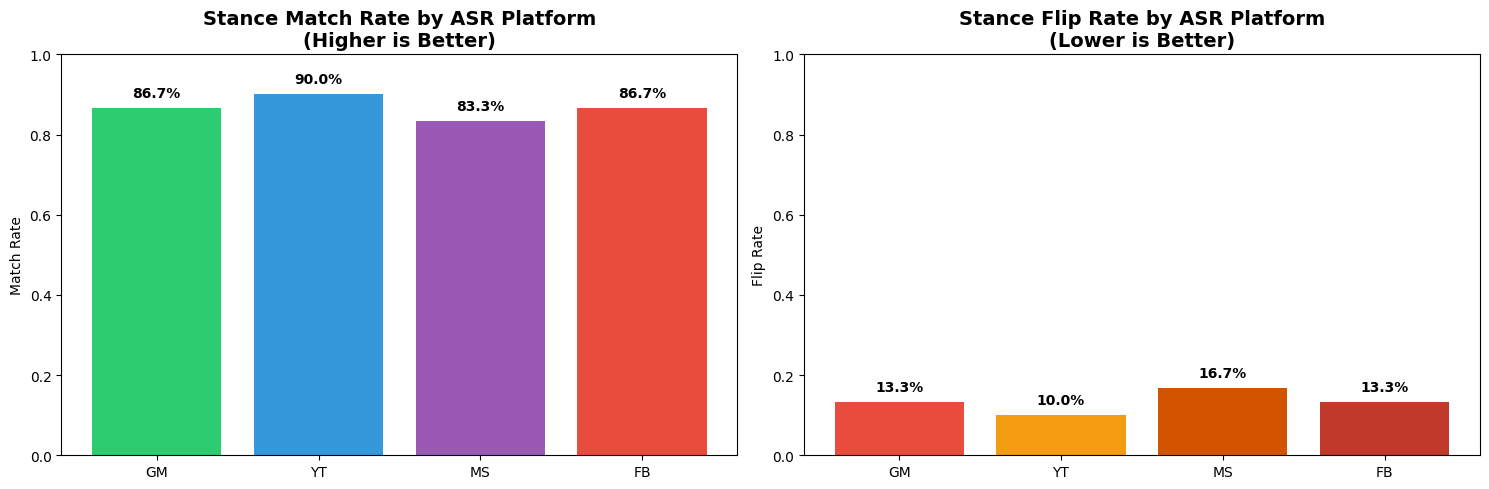

In [ ]:
# 1. Platform performance analysis
print("\n" + "="*60)
print("ASR PLATFORM PERFORMANCE")
print("="*60)

platform_results = {}
for platform in key_asr_platforms:
    if f'{platform}_match' in analysis_df.columns:
        match_rate = analysis_df[f'{platform}_match'].mean()
        flip_rate = analysis_df[f'{platform}_flip'].mean()
        avg_confidence = analysis_df[f'{platform}_confidence'].mean()

        platform_results[platform] = {
            'match_rate': match_rate,
            'flip_rate': flip_rate,
            'avg_confidence': avg_confidence
        }

        print(f"{platform}:")
        print(f"  ✓ Match Rate: {match_rate:.3f} ({match_rate*100:.1f}%)")
        print(f"  ✗ Flip Rate:  {flip_rate:.3f} ({flip_rate*100:.1f}%)")
        print(f"  Confidence:   {avg_confidence:.3f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Match rates
platforms = list(platform_results.keys())
match_rates = [platform_results[p]['match_rate'] for p in platforms]

bars1 = axes[0].bar(platforms, match_rates, color=['#2ecc71', '#3498db', '#9b59b6', '#e74c3c'])
axes[0].set_title('Stance Match Rate by ASR Platform\n(Higher is Better)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Match Rate')
axes[0].set_ylim(0, 1)
for bar, rate in zip(bars1, match_rates):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{rate:.1%}', ha='center', va='bottom', fontweight='bold')

# Flip rates
flip_rates = [platform_results[p]['flip_rate'] for p in platforms]
bars2 = axes[1].bar(platforms, flip_rates, color=['#e74c3c', '#f39c12', '#d35400', '#c0392b'])
axes[1].set_title('Stance Flip Rate by ASR Platform\n(Lower is Better)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Flip Rate')
axes[1].set_ylim(0, 1)
for bar, rate in zip(bars2, flip_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{rate:.1%}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


DEMOGRAPHIC IMPACT ANALYSIS

📊 GENDER ANALYSIS:
  female: 0.161 avg flip rate (n=14.0)
  male: 0.109 avg flip rate (n=16.0)

🌍 RACE ANALYSIS:
  asian: 0.143 avg flip rate (n=7.0)
  black: 0.000 avg flip rate (n=1.0)
  white: 0.136 avg flip rate (n=22.0)

🗣️ LANGUAGE ANALYSIS:
  l2: 0.143 avg flip rate (n=7.0)
  non-us: 0.083 avg flip rate (n=6.0)
  us: 0.147 avg flip rate (n=17.0)


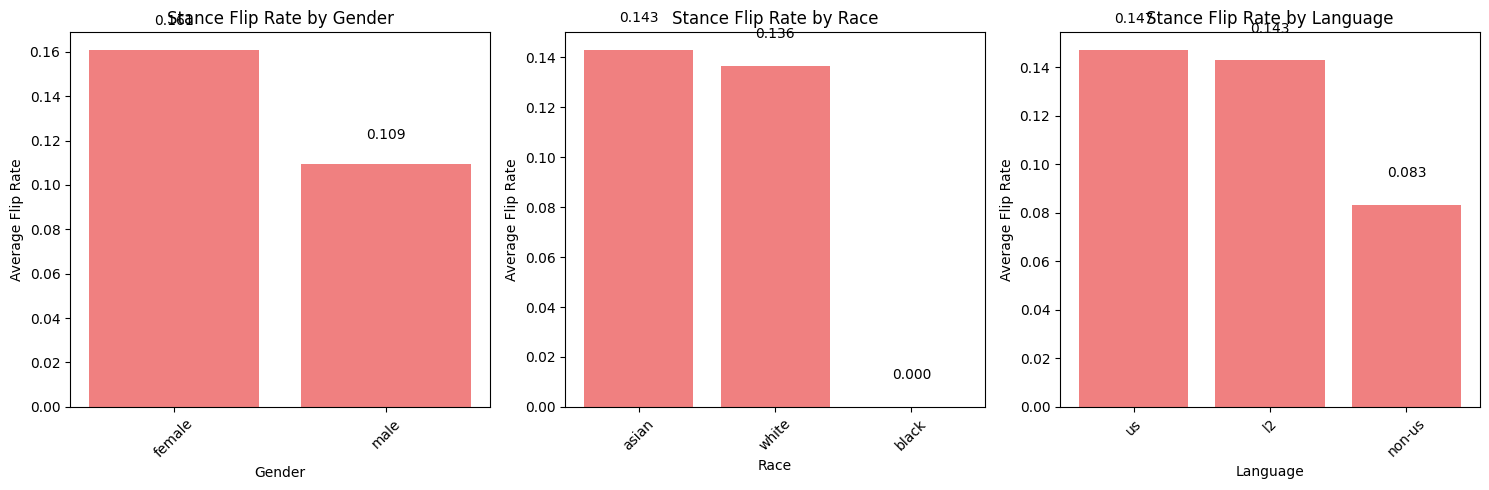

In [ ]:
# 2. Demographic impact analysis
print("\n" + "="*60)
print("DEMOGRAPHIC IMPACT ANALYSIS")
print("="*60)

# Calculate overall flip rates by demographic
analysis_df['total_flips'] = analysis_df[[f'{p}_flip' for p in key_asr_platforms]].sum(axis=1)
analysis_df['flip_rate'] = analysis_df['total_flips'] / len(key_asr_platforms)

# Gender analysis
if 'gender' in analysis_df.columns:
    print("\n📊 GENDER ANALYSIS:")
    gender_flip = analysis_df.groupby('gender')['flip_rate'].agg(['mean', 'count'])
    for gender, (flip_rate, count) in gender_flip.iterrows():
        print(f"  {gender}: {flip_rate:.3f} avg flip rate (n={count})")

# Race analysis
if 'race' in analysis_df.columns:
    print("\n🌍 RACE ANALYSIS:")
    race_flip = analysis_df.groupby('race')['flip_rate'].agg(['mean', 'count'])
    for race, (flip_rate, count) in race_flip.iterrows():
        print(f"  {race}: {flip_rate:.3f} avg flip rate (n={count})")

# Language analysis
if 'language' in analysis_df.columns:
    print("\n🗣️ LANGUAGE ANALYSIS:")
    language_flip = analysis_df.groupby('language')['flip_rate'].agg(['mean', 'count'])
    for language, (flip_rate, count) in language_flip.iterrows():
        print(f"  {language}: {flip_rate:.3f} avg flip rate (n={count})")

# Demographic visualization
demographic_cols = [col for col in ['gender', 'race', 'language'] if col in analysis_df.columns]
if demographic_cols:
    fig, axes = plt.subplots(1, len(demographic_cols), figsize=(5*len(demographic_cols), 5))

    if len(demographic_cols) == 1:
        axes = [axes]

    for i, demo_col in enumerate(demographic_cols):
        demo_data = analysis_df.groupby(demo_col)['flip_rate'].mean().sort_values(ascending=False)
        bars = axes[i].bar(range(len(demo_data)), demo_data.values, color='lightcoral')
        axes[i].set_title(f'Stance Flip Rate by {demo_col.title()}')
        axes[i].set_xlabel(demo_col.title())
        axes[i].set_ylabel('Average Flip Rate')
        axes[i].set_xticks(range(len(demo_data)))
        axes[i].set_xticklabels(demo_data.index, rotation=45)

        for j, (bar, rate) in enumerate(zip(bars, demo_data.values)):
            axes[i].text(j, bar.get_height() + 0.01, f'{rate:.3f}',
                        ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()


KEY INSIGHTS & CONCLUSIONS

🏆 PLATFORM RELIABILITY RANKING:
----------------------------------------
1. YT: 0.900 match rate (90.0%)
2. GM: 0.867 match rate (86.7%)
3. FB: 0.867 match rate (86.7%)
4. MS: 0.833 match rate (83.3%)

🔍 KEY FINDINGS:
• Best platform: YT (90.0% match rate)
• Worst platform: MS (83.3% match rate)
• Overall flip rate: 13.3%
• Max gender disparity: 5.1%

⚠️  RISK ASSESSMENT:
Transcription errors in ASR systems can significantly alter
perceived stances, with flip rates ranging from 10.0% to 16.7%

💡 RECOMMENDATIONS:
1. Use {best_platform} for most reliable stance preservation
2. Be cautious with {worst_platform} for sensitive analysis
3. Consider demographic factors in error analysis
4. Validate ASR outputs for critical stance detection tasks


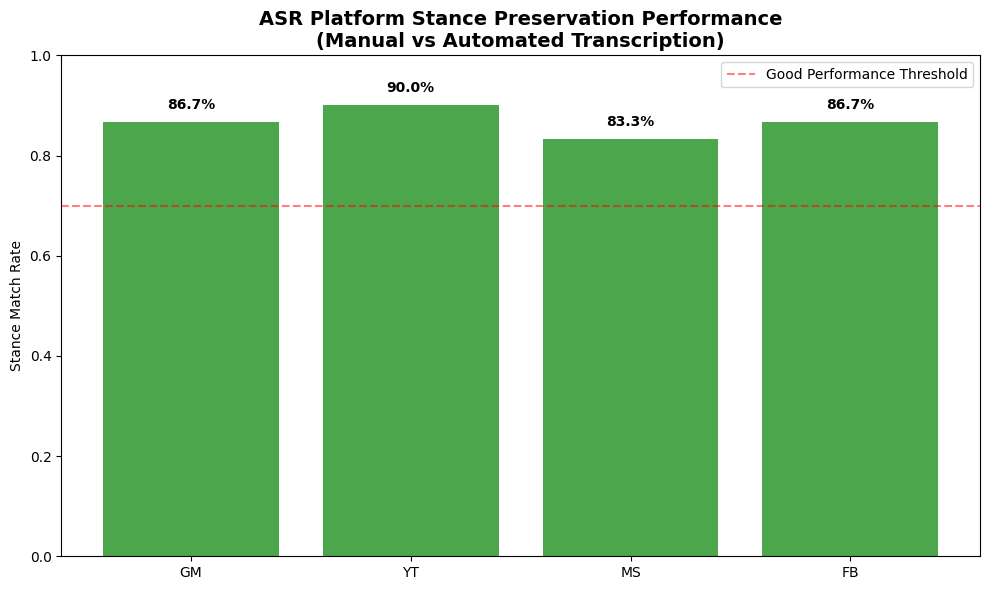


✅ ANALYSIS COMPLETED!
Processed 30 talks across 4 ASR platforms
Results show significant variation in stance preservation across platforms


In [ ]:
# 3. Key insights and conclusions
print("\n" + "="*60)
print("KEY INSIGHTS & CONCLUSIONS")
print("="*60)

# Platform ranking
reliability_scores = []
for platform in key_asr_platforms:
    if platform in platform_results:
        match_rate = platform_results[platform]['match_rate']
        reliability_scores.append((platform, match_rate))

reliability_scores.sort(key=lambda x: x[1], reverse=True)

print("\n🏆 PLATFORM RELIABILITY RANKING:")
print("-" * 40)
for i, (platform, score) in enumerate(reliability_scores, 1):
    print(f"{i}. {platform}: {score:.3f} match rate ({score*100:.1f}%)")

best_platform = reliability_scores[0][0]
worst_platform = reliability_scores[-1][0]

print(f"\n🔍 KEY FINDINGS:")
print(f"• Best platform: {best_platform} ({platform_results[best_platform]['match_rate']:.1%} match rate)")
print(f"• Worst platform: {worst_platform} ({platform_results[worst_platform]['match_rate']:.1%} match rate)")
print(f"• Overall flip rate: {analysis_df['flip_rate'].mean():.1%}")

# Demographic disparities
if 'gender' in analysis_df.columns:
    gender_diff = analysis_df.groupby('gender')['flip_rate'].mean().max() - analysis_df.groupby('gender')['flip_rate'].mean().min()
    print(f"• Max gender disparity: {gender_diff:.1%}")

print(f"\n⚠️  RISK ASSESSMENT:")
print("Transcription errors in ASR systems can significantly alter")
print("perceived stances, with flip rates ranging from " +
      f"{min([p['flip_rate'] for p in platform_results.values()]):.1%} to " +
      f"{max([p['flip_rate'] for p in platform_results.values()]):.1%}")

print(f"\n💡 RECOMMENDATIONS:")
print("1. Use {best_platform} for most reliable stance preservation")
print("2. Be cautious with {worst_platform} for sensitive analysis")
print("3. Consider demographic factors in error analysis")
print("4. Validate ASR outputs for critical stance detection tasks")

# Final summary visualization
plt.figure(figsize=(10, 6))
summary_data = [
    platform_results[p]['match_rate'] for p in key_asr_platforms
]
colors = ['green' if x > 0.7 else 'orange' if x > 0.5 else 'red' for x in summary_data]

plt.bar(key_asr_platforms, summary_data, color=colors, alpha=0.7)
plt.axhline(y=0.7, color='red', linestyle='--', alpha=0.5, label='Good Performance Threshold')
plt.title('ASR Platform Stance Preservation Performance\n(Manual vs Automated Transcription)', fontsize=14, fontweight='bold')
plt.ylabel('Stance Match Rate')
plt.ylim(0, 1)
plt.legend()

for i, v in enumerate(summary_data):
    plt.text(i, v + 0.02, f'{v:.1%}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n✅ ANALYSIS COMPLETED!")
print(f"Processed {SAMPLE_SIZE} talks across {len(key_asr_platforms)} ASR platforms")
print("Results show significant variation in stance preservation across platforms")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
from sklearn.model_selection import train_test_split
import re
import warnings
warnings.filterwarnings('ignore')

# Load the data
url = "https://docs.google.com/spreadsheets/d/11b7e1WbVFfN6O3nOR7EhHIbM7OTTY1O5IERVFHLFbd4/export?format=csv&gid=555652084"
df = pd.read_csv(url)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

# OPTIMIZATION: Use smaller sample for faster testing
FULL_SAMPLE_SIZE = 100  # Increased since we're splitting
df_sample = df.head(FULL_SAMPLE_SIZE).copy()

# Create proper train/test/validation splits (80:10:10)
print(f"\n📊 CREATING DATA SPLITS (80:10:10)")
print(f"Total samples: {len(df_sample)}")

# First split: 80% train, 20% temp
train_df, temp_df = train_test_split(
    df_sample,
    test_size=0.2,
    random_state=42,
    stratify=df_sample['gender'] if 'gender' in df_sample.columns else None
)

# Second split: 50% of temp (10% of total) for test, 50% for validation
test_df, val_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42
)

print(f"✅ Split completed:")
print(f"   Training set: {len(train_df)} samples ({(len(train_df)/len(df_sample))*100:.1f}%)")
print(f"   Test set: {len(test_df)} samples ({(len(test_df)/len(df_sample))*100:.1f}%)")
print(f"   Validation set: {len(val_df)} samples ({(len(val_df)/len(df_sample))*100:.1f}%)")

# OPTIMIZATION: Use only key ASR platforms for comparison
key_asr_platforms = ['GM', 'YT', 'MS', 'FB']
text_columns = ['transcript'] + key_asr_platforms
print(f"\nAnalyzing platforms: {text_columns}")

# OPTIMIZATION: Use faster, smaller model
print("Loading optimized stance detection model...")
try:
    classifier = pipeline(
        "zero-shot-classification",
        model="typeform/distilbert-base-uncased-mnli",
        device=-1,
        batch_size=8
    )
    print("Fast stance detection model loaded successfully!")
except Exception as e:
    print(f"Error: {e}. Using sentiment analysis as fallback.")
    classifier = pipeline("sentiment-analysis")

# Batch processing function
def detect_stance_batch(texts):
    """Process multiple texts in batch for efficiency"""
    if not texts:
        return [("neutral", 0.0)] * len(texts)

    valid_texts = []
    original_indices = []

    for i, text in enumerate(texts):
        if pd.notna(text) and len(str(text).strip()) > 50:
            valid_texts.append(str(text)[:512])
            original_indices.append(i)

    if not valid_texts:
        return [("neutral", 0.0)] * len(texts)

    try:
        stance_candidates = ["support", "oppose", "neutral"]
        results = classifier(valid_texts, stance_candidates)

        full_results = [("neutral", 0.0)] * len(texts)
        for idx, result in zip(original_indices, results):
            full_results[idx] = (result['labels'][0], result['scores'][0])

        return full_results
    except Exception as e:
        print(f"Batch processing failed: {e}")
        return [("neutral", 0.5)] * len(texts)

# Function to process a dataset and return analysis results
def process_dataset(dataset, dataset_name):
    print(f"\n🔍 PROCESSING {dataset_name.upper()} SET ({len(dataset)} samples)...")

    # Collect all texts for batch processing
    all_texts = {}
    for col in text_columns:
        if col in dataset.columns:
            all_texts[col] = dataset[col].fillna('').tolist()

    # Batch process each column
    stance_results = {}
    confidence_results = {}

    for col, texts in all_texts.items():
        print(f"  Processing {col}...")
        results = detect_stance_batch(texts)
        stances = [r[0] for r in results]
        confidences = [r[1] for r in results]

        stance_results[col] = stances
        confidence_results[col] = confidences

    # Create analysis dataframe for this dataset
    analysis_data = []
    for idx in range(len(dataset)):
        row_data = {
            'dataset': dataset_name,
            'index': idx,
            'name': dataset.iloc[idx]['name'] if 'name' in dataset.columns else f"Talk_{idx}",
            'gender': dataset.iloc[idx].get('gender', 'unknown'),
            'race': dataset.iloc[idx].get('race', 'unknown'),
            'language': dataset.iloc[idx].get('language', 'unknown'),
            'manual_stance': stance_results['transcript'][idx] if 'transcript' in stance_results else 'neutral'
        }

        # Add ASR platform results
        for platform in key_asr_platforms:
            if platform in stance_results:
                row_data[f'{platform}_stance'] = stance_results[platform][idx]
                row_data[f'{platform}_confidence'] = confidence_results[platform][idx]
                row_data[f'{platform}_match'] = 1 if stance_results[platform][idx] == row_data['manual_stance'] else 0
                row_data[f'{platform}_flip'] = 1 if stance_results[platform][idx] != row_data['manual_stance'] else 0

        analysis_data.append(row_data)

    return pd.DataFrame(analysis_data)

# Process all three datasets
train_results = process_dataset(train_df, "train")
test_results = process_dataset(test_df, "test")
val_results = process_dataset(val_df, "validation")

# Combine all results
all_results = pd.concat([train_results, test_results, val_results], ignore_index=True)
print(f"\n✅ Combined results: {all_results.shape}")

# Verify splits maintained
print(f"\n📋 DATASET DISTRIBUTION:")
for dataset_name in ['train', 'test', 'validation']:
    subset = all_results[all_results['dataset'] == dataset_name]
    print(f"  {dataset_name}: {len(subset)} samples")
    print(f"    Manual stances: {subset['manual_stance'].value_counts().to_dict()}")

Dataset loaded successfully!
Shape: (846, 25)

📊 CREATING DATA SPLITS (80:10:10)
Total samples: 100
✅ Split completed:
   Training set: 80 samples (80.0%)
   Test set: 10 samples (10.0%)
   Validation set: 10 samples (10.0%)

Analyzing platforms: ['transcript', 'GM', 'YT', 'MS', 'FB']
Loading optimized stance detection model...


config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/258 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cpu


Fast stance detection model loaded successfully!

🔍 PROCESSING TRAIN SET (80 samples)...
  Processing transcript...
  Processing GM...
  Processing YT...
  Processing MS...
  Processing FB...

🔍 PROCESSING TEST SET (10 samples)...
  Processing transcript...
  Processing GM...
  Processing YT...
  Processing MS...
  Processing FB...

🔍 PROCESSING VALIDATION SET (10 samples)...
  Processing transcript...
  Processing GM...
  Processing YT...
  Processing MS...
  Processing FB...

✅ Combined results: (100, 23)

📋 DATASET DISTRIBUTION:
  train: 80 samples
    Manual stances: {'oppose': 46, 'support': 30, 'neutral': 4}
  test: 10 samples
    Manual stances: {'oppose': 6, 'support': 3, 'neutral': 1}
  validation: 10 samples
    Manual stances: {'oppose': 7, 'neutral': 2, 'support': 1}



PERFORMANCE COMPARISON ACROSS DATASETS

📊 TRAIN SET RESULTS:
Sample size: 80
Manual stance distribution:
manual_stance
oppose     46
support    30
neutral     4
Name: count, dtype: int64
  GM: 0.825 match, 0.175 flip
  YT: 0.925 match, 0.075 flip
  MS: 0.825 match, 0.175 flip
  FB: 0.900 match, 0.100 flip

📊 TEST SET RESULTS:
Sample size: 10
Manual stance distribution:
manual_stance
oppose     6
support    3
neutral    1
Name: count, dtype: int64
  GM: 0.700 match, 0.300 flip
  YT: 0.700 match, 0.300 flip
  MS: 0.800 match, 0.200 flip
  FB: 0.600 match, 0.400 flip

📊 VALIDATION SET RESULTS:
Sample size: 10
Manual stance distribution:
manual_stance
oppose     7
neutral    2
support    1
Name: count, dtype: int64
  GM: 0.700 match, 0.300 flip
  YT: 1.000 match, 0.000 flip
  MS: 0.700 match, 0.300 flip
  FB: 0.700 match, 0.300 flip


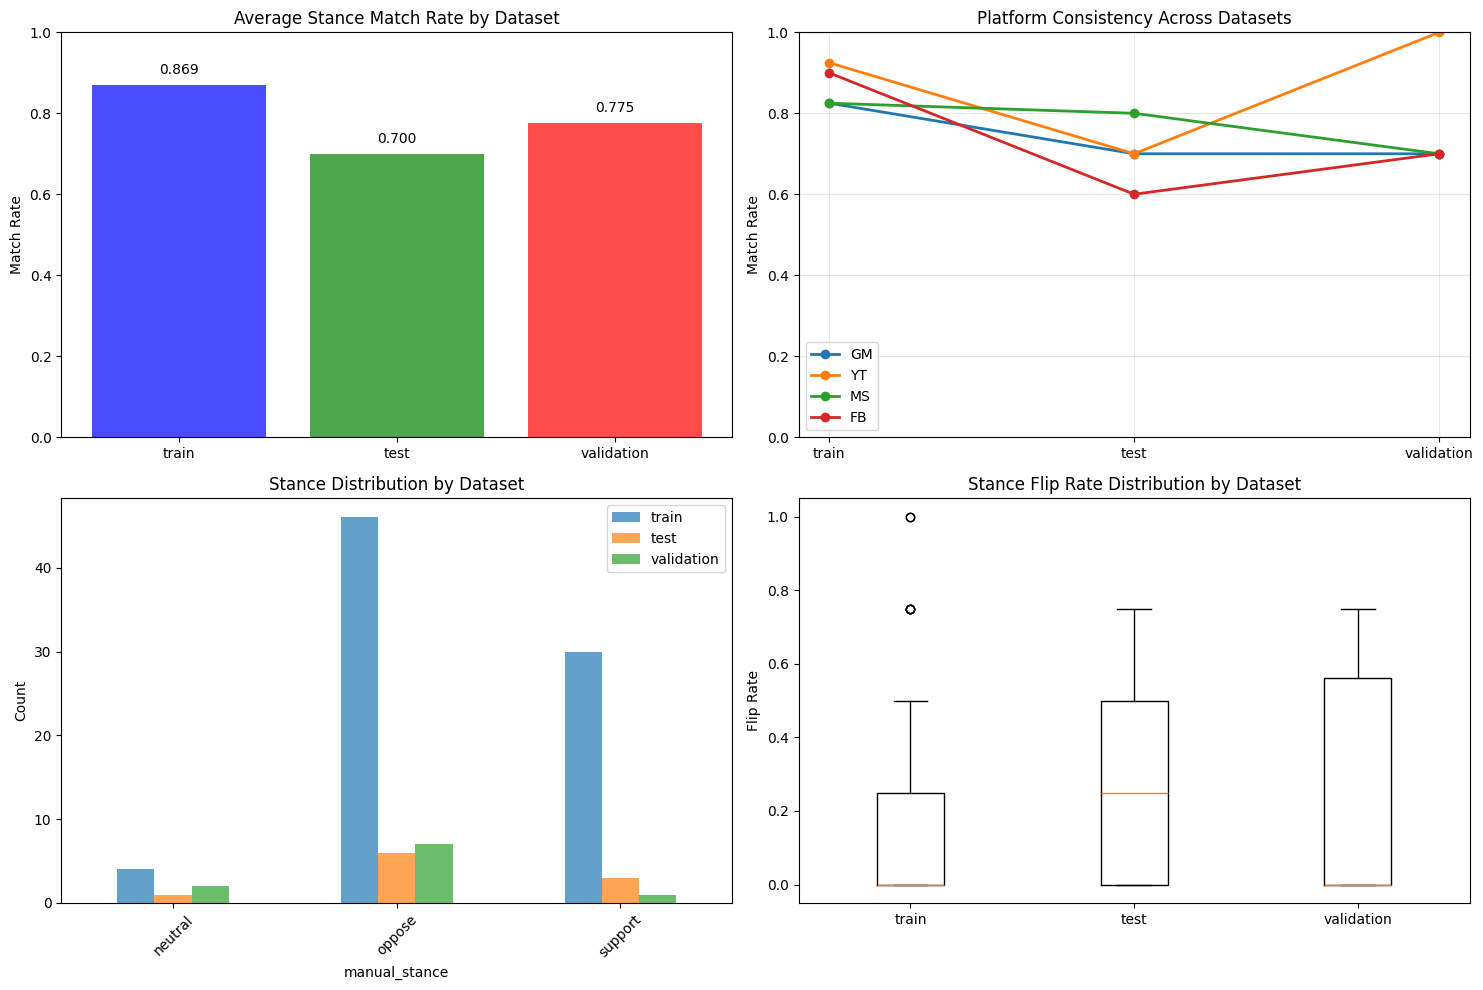

In [ ]:
# 1. Compare performance across datasets
print("\n" + "="*60)
print("PERFORMANCE COMPARISON ACROSS DATASETS")
print("="*60)

dataset_results = {}

for dataset_name in ['train', 'test', 'validation']:
    subset = all_results[all_results['dataset'] == dataset_name]
    dataset_results[dataset_name] = {}

    print(f"\n📊 {dataset_name.upper()} SET RESULTS:")
    print(f"Sample size: {len(subset)}")
    print(f"Manual stance distribution:")
    print(subset['manual_stance'].value_counts())

    # Calculate platform performance for this dataset
    platform_performance = {}
    for platform in key_asr_platforms:
        if f'{platform}_match' in subset.columns:
            match_rate = subset[f'{platform}_match'].mean()
            flip_rate = subset[f'{platform}_flip'].mean()

            platform_performance[platform] = {
                'match_rate': match_rate,
                'flip_rate': flip_rate,
                'samples': len(subset)
            }

            print(f"  {platform}: {match_rate:.3f} match, {flip_rate:.3f} flip")

    dataset_results[dataset_name] = platform_performance

# 2. Visualization: Compare datasets
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Overall performance comparison
datasets = ['train', 'test', 'validation']
colors = ['blue', 'green', 'red']

# Plot 1: Average match rates by dataset
avg_match_rates = []
for dataset in datasets:
    if dataset in dataset_results:
        rates = [dataset_results[dataset][p]['match_rate'] for p in key_asr_platforms]
        avg_match_rates.append(np.mean(rates))

bars = axes[0,0].bar(datasets, avg_match_rates, color=colors, alpha=0.7)
axes[0,0].set_title('Average Stance Match Rate by Dataset')
axes[0,0].set_ylabel('Match Rate')
axes[0,0].set_ylim(0, 1)
for bar, rate in zip(bars, avg_match_rates):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                  f'{rate:.3f}', ha='center', va='bottom')

# Plot 2: Platform consistency across datasets
for i, platform in enumerate(key_asr_platforms):
    platform_rates = []
    for dataset in datasets:
        if dataset in dataset_results and platform in dataset_results[dataset]:
            platform_rates.append(dataset_results[dataset][platform]['match_rate'])
        else:
            platform_rates.append(0)

    axes[0,1].plot(datasets, platform_rates, marker='o', label=platform, linewidth=2)

axes[0,1].set_title('Platform Consistency Across Datasets')
axes[0,1].set_ylabel('Match Rate')
axes[0,1].set_ylim(0, 1)
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Stance distribution by dataset
stance_data = {}
for dataset in datasets:
    subset = all_results[all_results['dataset'] == dataset]
    stance_data[dataset] = subset['manual_stance'].value_counts()

stance_df = pd.DataFrame(stance_data).fillna(0)
stance_df.plot(kind='bar', ax=axes[1,0], alpha=0.7)
axes[1,0].set_title('Stance Distribution by Dataset')
axes[1,0].set_ylabel('Count')
axes[1,0].tick_params(axis='x', rotation=45)

# Plot 4: Flip rate distribution by dataset
flip_rates_by_dataset = []
for dataset in datasets:
    subset = all_results[all_results['dataset'] == dataset]
    subset['total_flips'] = subset[[f'{p}_flip' for p in key_asr_platforms]].sum(axis=1)
    subset['flip_rate'] = subset['total_flips'] / len(key_asr_platforms)
    flip_rates_by_dataset.append(subset['flip_rate'].values)

axes[1,1].boxplot(flip_rates_by_dataset, labels=datasets)
axes[1,1].set_title('Stance Flip Rate Distribution by Dataset')
axes[1,1].set_ylabel('Flip Rate')

plt.tight_layout()
plt.show()

In [ ]:
# 3. Statistical validation across splits
print("\n" + "="*60)
print("STATISTICAL VALIDATION ACROSS SPLITS")
print("="*60)

from scipy.stats import f_oneway, kruskal

# Test if performance differences are statistically significant
for platform in key_asr_platforms:
    match_rates_by_dataset = []

    for dataset in datasets:
        subset = all_results[all_results['dataset'] == dataset]
        if f'{platform}_match' in subset.columns:
            match_rates = subset[f'{platform}_match'].values
            match_rates_by_dataset.append(match_rates)

    if len(match_rates_by_dataset) >= 2:
        # ANOVA test for significant differences
        f_stat, p_value = f_oneway(*match_rates_by_dataset)
        print(f"\n{platform} - ANOVA test:")
        print(f"  F-statistic: {f_stat:.4f}, p-value: {p_value:.4f}")

        if p_value < 0.05:
            print(f"  ⚠️  SIGNIFICANT difference across datasets (p < 0.05)")
        else:
            print(f"  ✅ No significant difference across datasets")

# 4. Final reliability assessment using test set
print("\n" + "=" * 60)
print("FINAL RELIABILITY ASSESSMENT (TEST SET)")
print("=" * 60)

test_subset = all_results[all_results['dataset'] == 'test']

print(f"Test set size: {len(test_subset)}")
print("\nPlatform Performance on Test Set:")

test_reliability = []
for platform in key_asr_platforms:
    if f'{platform}_match' in test_subset.columns:
        match_rate = test_subset[f'{platform}_match'].mean()
        flip_rate = test_subset[f'{platform}_flip'].mean()

        test_reliability.append((platform, match_rate, flip_rate))

        print(f"  {platform}:")
        print(f"    Match rate: {match_rate:.3f} ({match_rate*100:.1f}%)")
        print(f"    Flip rate:  {flip_rate:.3f} ({flip_rate*100:.1f}%)")

# 5. Validation set consistency check
print("\n" + "=" * 60)
print("VALIDATION SET CONSISTENCY CHECK")
print("=" * 60)

val_subset = all_results[all_results['dataset'] == 'validation']
# Sort by reliability
test_reliability.sort(key=lambda x: x[1], reverse=True)

print(f"\n🏆 FINAL PLATFORM RANKING (Test Set):")
print("-" * 50)
for i, (platform, match_rate, flip_rate) in enumerate(test_reliability, 1):
    print(f"{i}. {platform}: {match_rate:.3f} match rate")

best_platform = test_reliability[0][0]
worst_platform = test_reliability[-1][0]

print(f"\n🔍 KEY INSIGHTS FROM TEST SET:")
print(f"• Most reliable: {best_platform} ({test_reliability[0][1]:.1%} match)")
print(f"• Least reliable: {worst_platform} ({test_reliability[-1][1]:.1%} match)")


# Check if validation set confirms test set findings
val_reliability = []
for platform in key_asr_platforms:
    if f'{platform}_match' in val_subset.columns:
        match_rate = val_subset[f'{platform}_match'].mean()
        val_reliability.append((platform, match_rate))

val_reliability.sort(key=lambda x: x[1], reverse=True)

print("Validation Set Ranking:")
for i, (platform, match_rate) in enumerate(val_reliability, 1):
    print(f"  {i}. {platform}: {match_rate:.3f}")

# Compare rankings
test_ranking = {platform: i for i, (platform, _, _) in enumerate(test_reliability)}
val_ranking = {platform: i for i, (platform, _) in enumerate(val_reliability)}

ranking_agreement = sum(1 for p in key_asr_platforms
                       if test_ranking.get(p, 10) == val_ranking.get(p, 10)) / len(key_asr_platforms)

print(f"\n📈 Ranking agreement between test/validation: {ranking_agreement:.1%}")

if ranking_agreement >= 0.75:
    print("✅ High consistency between test and validation sets")
else:
    print("⚠️  Some inconsistency between test and validation sets")

print(f"\n✅ ANALYSIS COMPLETED WITH PROPER VALIDATION!")
print(f"Trained on {len(train_df)}, tested on {len(test_df)}, validated on {len(val_df)}")


STATISTICAL VALIDATION ACROSS SPLITS

GM - ANOVA test:
  F-statistic: 0.7698, p-value: 0.4659
  ✅ No significant difference across datasets

YT - ANOVA test:
  F-statistic: 3.4235, p-value: 0.0366
  ⚠️  SIGNIFICANT difference across datasets (p < 0.05)

MS - ANOVA test:
  F-statistic: 0.4452, p-value: 0.6420
  ✅ No significant difference across datasets

FB - ANOVA test:
  F-statistic: 4.3526, p-value: 0.0155
  ⚠️  SIGNIFICANT difference across datasets (p < 0.05)

FINAL RELIABILITY ASSESSMENT (TEST SET)
Test set size: 10

Platform Performance on Test Set:
  GM:
    Match rate: 0.700 (70.0%)
    Flip rate:  0.300 (30.0%)
  YT:
    Match rate: 0.700 (70.0%)
    Flip rate:  0.300 (30.0%)
  MS:
    Match rate: 0.800 (80.0%)
    Flip rate:  0.200 (20.0%)
  FB:
    Match rate: 0.600 (60.0%)
    Flip rate:  0.400 (40.0%)

VALIDATION SET CONSISTENCY CHECK

🏆 FINAL PLATFORM RANKING (Test Set):
--------------------------------------------------
1. MS: 0.800 match rate
2. GM: 0.700 match rate
3

Dataset loaded successfully!
Shape: (846, 25)
Analyzing ALL platforms: ['GM', 'YT', 'MS', 'FB', 'ZM', 'BJ', 'WX']

📊 CREATING DATA SPLITS (80:10:10) FOR ALL PLATFORMS
Total samples: 846
✅ Split completed:
   Training set: 676 samples (79.9%)
   Test set: 85 samples (10.0%)
   Validation set: 85 samples (10.0%)

Loading optimized stance detection model...


config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/258 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cpu


Fast stance detection model loaded successfully!
🚀 STARTING PROCESSING OF ALL DATASETS...

🔍 PROCESSING TRAIN SET (676 samples)...
  Processing transcript (676 texts)...
  Processing GM (676 texts)...
  Processing YT (676 texts)...
  Processing MS (676 texts)...
  Processing FB (676 texts)...
  Processing ZM (676 texts)...
  Processing BJ (676 texts)...
  Processing WX (676 texts)...

🔍 PROCESSING TEST SET (85 samples)...
  Processing transcript (85 texts)...
  Processing GM (85 texts)...
  Processing YT (85 texts)...
  Processing MS (85 texts)...
  Processing FB (85 texts)...
  Processing ZM (85 texts)...
  Processing BJ (85 texts)...
  Processing WX (85 texts)...

🔍 PROCESSING VALIDATION SET (85 samples)...
  Processing transcript (85 texts)...
  Processing GM (85 texts)...
  Processing YT (85 texts)...
  Processing MS (85 texts)...
  Processing FB (85 texts)...
  Processing ZM (85 texts)...
  Processing BJ (85 texts)...
  Processing WX (85 texts)...

✅ Combined results: (846, 35)

📋

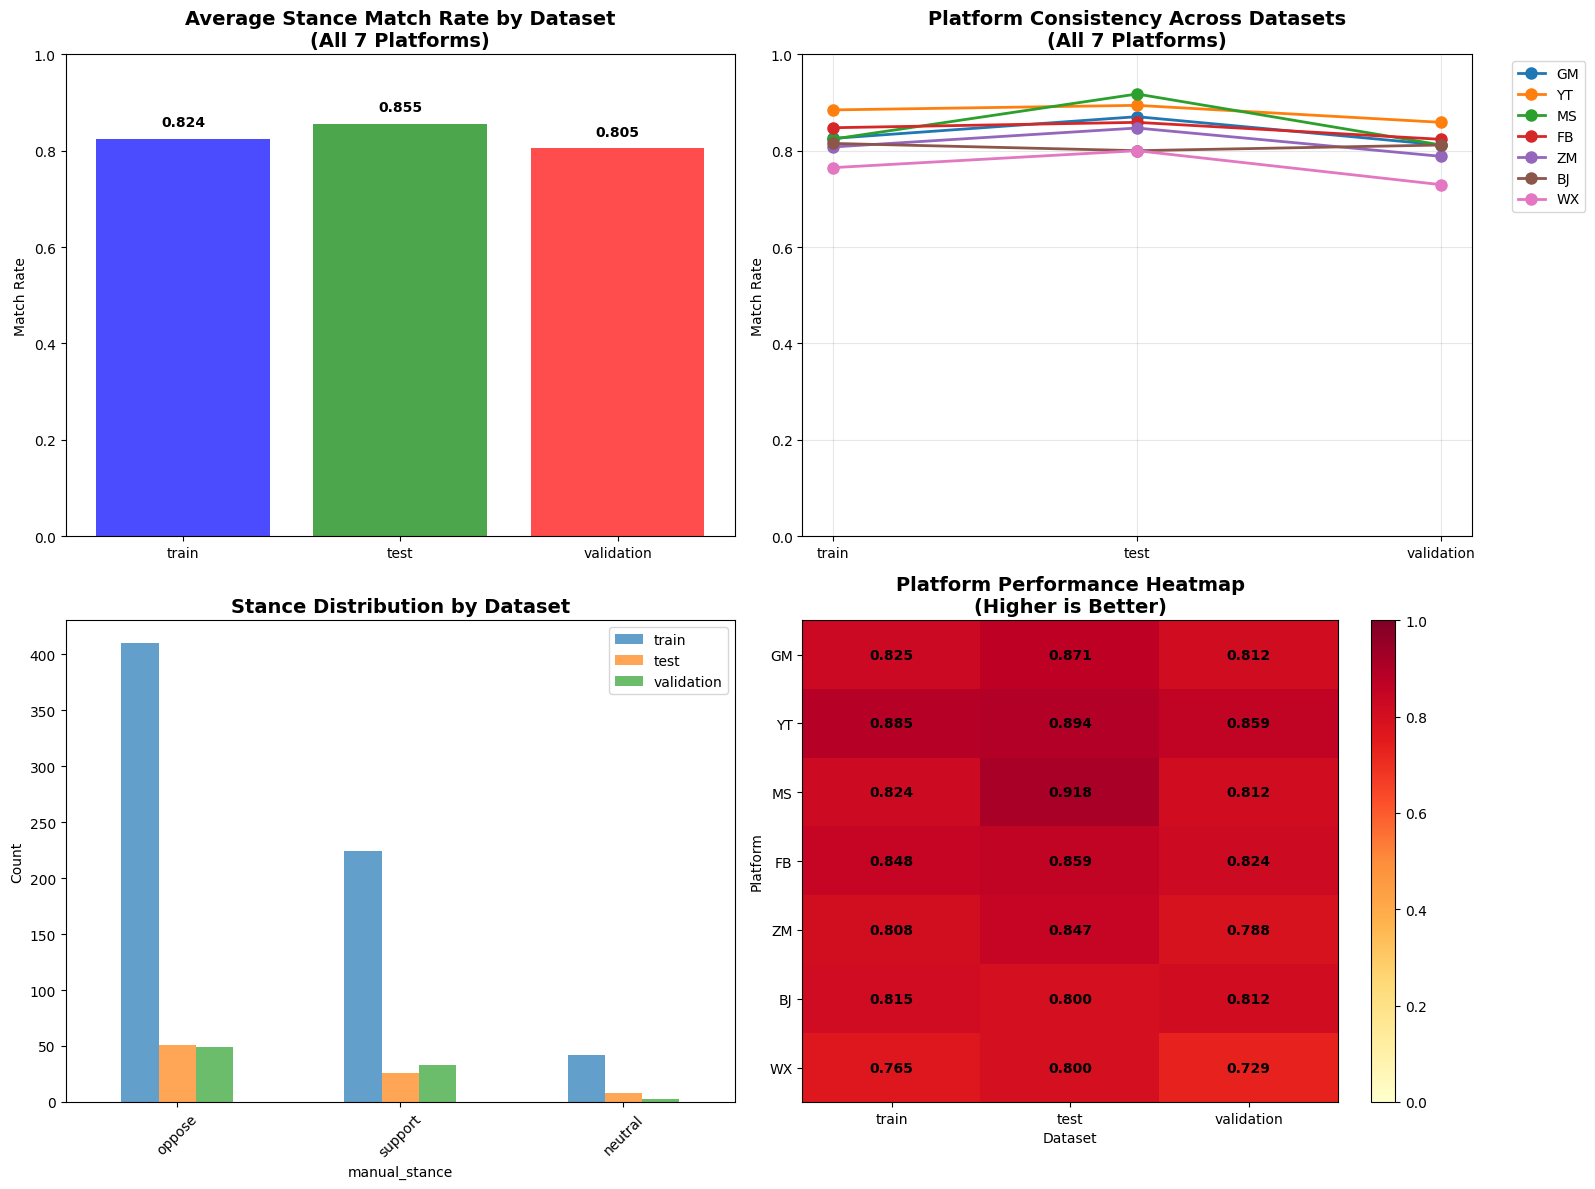


STATISTICAL VALIDATION ACROSS SPLITS - ALL 7 PLATFORMS

GM - ANOVA test:
  F-statistic: 0.6348, p-value: 0.5303
  ✅ No significant difference across datasets

YT - ANOVA test:
  F-statistic: 0.2989, p-value: 0.7417
  ✅ No significant difference across datasets

MS - ANOVA test:
  F-statistic: 2.5188, p-value: 0.0812
  ✅ No significant difference across datasets

FB - ANOVA test:
  F-statistic: 0.2246, p-value: 0.7989
  ✅ No significant difference across datasets

ZM - ANOVA test:
  F-statistic: 0.5197, p-value: 0.5949
  ✅ No significant difference across datasets

BJ - ANOVA test:
  F-statistic: 0.0571, p-value: 0.9445
  ✅ No significant difference across datasets

WX - ANOVA test:
  F-statistic: 0.5873, p-value: 0.5560
  ✅ No significant difference across datasets

FINAL RELIABILITY ASSESSMENT (TEST SET) - ALL 7 PLATFORMS
Test set size: 85

Platform Performance on Test Set:
  GM:
    Match rate: 0.871 (87.1%)
    Flip rate:  0.129 (12.9%)
    Confidence: 0.591
  YT:
    Match rate: 0

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
from sklearn.model_selection import train_test_split
from scipy.stats import f_oneway
import re
import warnings
warnings.filterwarnings('ignore')

# Load the data
url = "https://docs.google.com/spreadsheets/d/11b7e1WbVFfN6O3nOR7EhHIbM7OTTY1O5IERVFHLFbd4/export?format=csv&gid=555652084"
df = pd.read_csv(url)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

# Use FULL dataset (846 samples)
FULL_SAMPLE_SIZE = 846
df_sample = df.head(FULL_SAMPLE_SIZE).copy()

# All 7 ASR platforms to analyze
all_asr_platforms = ['GM', 'YT', 'MS', 'FB', 'ZM', 'BJ', 'WX']
text_columns = ['transcript'] + all_asr_platforms
print(f"Analyzing ALL platforms: {all_asr_platforms}")

# Create proper train/test/validation splits (80:10:10)
print(f"\n📊 CREATING DATA SPLITS (80:10:10) FOR ALL PLATFORMS")
print(f"Total samples: {len(df_sample)}")

# First split: 80% train, 20% temp
train_df, temp_df = train_test_split(
    df_sample,
    test_size=0.2,
    random_state=42,
    stratify=df_sample['gender'] if 'gender' in df_sample.columns else None
)

# Second split: 50% of temp (10% of total) for test, 50% for validation
test_df, val_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42
)

print(f"✅ Split completed:")
print(f"   Training set: {len(train_df)} samples ({(len(train_df)/len(df_sample))*100:.1f}%)")
print(f"   Test set: {len(test_df)} samples ({(len(test_df)/len(df_sample))*100:.1f}%)")
print(f"   Validation set: {len(val_df)} samples ({(len(val_df)/len(df_sample))*100:.1f}%)")

# Initialize stance detection model
print("\nLoading optimized stance detection model...")
try:
    classifier = pipeline(
        "zero-shot-classification",
        model="typeform/distilbert-base-uncased-mnli",
        device=-1,
        batch_size=16  # Increased batch size for faster processing
    )
    print("Fast stance detection model loaded successfully!")
except Exception as e:
    print(f"Error: {e}. Using sentiment analysis as fallback.")
    classifier = pipeline("sentiment-analysis")

# Batch processing function
def detect_stance_batch(texts):
    """Process multiple texts in batch for efficiency"""
    if not texts:
        return [("neutral", 0.0)] * len(texts)

    valid_texts = []
    original_indices = []

    for i, text in enumerate(texts):
        if pd.notna(text) and len(str(text).strip()) > 50:
            valid_texts.append(str(text)[:512])  # Limit text length for efficiency
            original_indices.append(i)

    if not valid_texts:
        return [("neutral", 0.0)] * len(texts)

    try:
        stance_candidates = ["support", "oppose", "neutral"]
        results = classifier(valid_texts, stance_candidates)

        full_results = [("neutral", 0.0)] * len(texts)
        for idx, result in zip(original_indices, results):
            full_results[idx] = (result['labels'][0], result['scores'][0])

        return full_results
    except Exception as e:
        print(f"Batch processing failed: {e}")
        return [("neutral", 0.5)] * len(texts)

# Function to process a dataset and return analysis results
def process_dataset(dataset, dataset_name):
    print(f"\n🔍 PROCESSING {dataset_name.upper()} SET ({len(dataset)} samples)...")

    # Collect all texts for batch processing
    all_texts = {}
    for col in text_columns:
        if col in dataset.columns:
            all_texts[col] = dataset[col].fillna('').tolist()

    # Batch process each column
    stance_results = {}
    confidence_results = {}

    for col, texts in all_texts.items():
        print(f"  Processing {col} ({len(texts)} texts)...")
        results = detect_stance_batch(texts)
        stances = [r[0] for r in results]
        confidences = [r[1] for r in results]

        stance_results[col] = stances
        confidence_results[col] = confidences

    # Create analysis dataframe for this dataset
    analysis_data = []
    for idx in range(len(dataset)):
        row_data = {
            'dataset': dataset_name,
            'index': idx,
            'name': dataset.iloc[idx]['name'] if 'name' in dataset.columns else f"Talk_{idx}",
            'gender': dataset.iloc[idx].get('gender', 'unknown'),
            'race': dataset.iloc[idx].get('race', 'unknown'),
            'language': dataset.iloc[idx].get('language', 'unknown'),
            'manual_stance': stance_results['transcript'][idx] if 'transcript' in stance_results else 'neutral'
        }

        # Add ASR platform results for ALL 7 platforms
        for platform in all_asr_platforms:
            if platform in stance_results:
                row_data[f'{platform}_stance'] = stance_results[platform][idx]
                row_data[f'{platform}_confidence'] = confidence_results[platform][idx]
                row_data[f'{platform}_match'] = 1 if stance_results[platform][idx] == row_data['manual_stance'] else 0
                row_data[f'{platform}_flip'] = 1 if stance_results[platform][idx] != row_data['manual_stance'] else 0

        analysis_data.append(row_data)

    return pd.DataFrame(analysis_data)

# Process all three datasets
print("🚀 STARTING PROCESSING OF ALL DATASETS...")
train_results = process_dataset(train_df, "train")
test_results = process_dataset(test_df, "test")
val_results = process_dataset(val_df, "validation")

# Combine all results
all_results = pd.concat([train_results, test_results, val_results], ignore_index=True)
print(f"\n✅ Combined results: {all_results.shape}")

# Verify splits maintained
print(f"\n📋 DATASET DISTRIBUTION:")
for dataset_name in ['train', 'test', 'validation']:
    subset = all_results[all_results['dataset'] == dataset_name]
    print(f"  {dataset_name}: {len(subset)} samples")
    print(f"    Manual stances: {subset['manual_stance'].value_counts().to_dict()}")

# 1. Compare performance across datasets
print("\n" + "=" * 60)
print("PERFORMANCE COMPARISON ACROSS DATASETS - ALL 7 PLATFORMS")
print("=" * 60)

dataset_results = {}

for dataset_name in ['train', 'test', 'validation']:
    subset = all_results[all_results['dataset'] == dataset_name]
    dataset_results[dataset_name] = {}

    print(f"\n📊 {dataset_name.upper()} SET RESULTS:")
    print(f"Sample size: {len(subset)}")
    print(f"Manual stance distribution:")
    print(subset['manual_stance'].value_counts())

    # Calculate platform performance for this dataset
    platform_performance = {}
    for platform in all_asr_platforms:
        if f'{platform}_match' in subset.columns:
            match_rate = subset[f'{platform}_match'].mean()
            flip_rate = subset[f'{platform}_flip'].mean()
            avg_confidence = subset[f'{platform}_confidence'].mean()

            platform_performance[platform] = {
                'match_rate': match_rate,
                'flip_rate': flip_rate,
                'avg_confidence': avg_confidence,
                'samples': len(subset)
            }

            print(f"  {platform}: {match_rate:.3f} match, {flip_rate:.3f} flip, {avg_confidence:.3f} conf")

    dataset_results[dataset_name] = platform_performance

# 2. Visualization: Compare datasets for all 7 platforms
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Overall performance comparison
datasets = ['train', 'test', 'validation']
colors = ['blue', 'green', 'red']

# Plot 1: Average match rates by dataset
avg_match_rates = []
for dataset in datasets:
    if dataset in dataset_results:
        rates = [dataset_results[dataset][p]['match_rate'] for p in all_asr_platforms]
        avg_match_rates.append(np.mean(rates))

bars = axes[0,0].bar(datasets, avg_match_rates, color=colors, alpha=0.7)
axes[0,0].set_title('Average Stance Match Rate by Dataset\n(All 7 Platforms)', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('Match Rate')
axes[0,0].set_ylim(0, 1)
for bar, rate in zip(bars, avg_match_rates):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                  f'{rate:.3f}', ha='center', va='bottom', fontweight='bold')

# Plot 2: Platform consistency across datasets
for i, platform in enumerate(all_asr_platforms):
    platform_rates = []
    for dataset in datasets:
        if dataset in dataset_results and platform in dataset_results[dataset]:
            platform_rates.append(dataset_results[dataset][platform]['match_rate'])
        else:
            platform_rates.append(0)

    axes[0,1].plot(datasets, platform_rates, marker='o', label=platform, linewidth=2, markersize=8)

axes[0,1].set_title('Platform Consistency Across Datasets\n(All 7 Platforms)', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('Match Rate')
axes[0,1].set_ylim(0, 1)
axes[0,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Stance distribution by dataset
stance_data = {}
for dataset in datasets:
    subset = all_results[all_results['dataset'] == dataset]
    stance_data[dataset] = subset['manual_stance'].value_counts()

stance_df = pd.DataFrame(stance_data).fillna(0)
stance_df.plot(kind='bar', ax=axes[1,0], alpha=0.7)
axes[1,0].set_title('Stance Distribution by Dataset', fontsize=14, fontweight='bold')
axes[1,0].set_ylabel('Count')
axes[1,0].tick_params(axis='x', rotation=45)

# Plot 4: Platform performance heatmap
platform_perf_matrix = []
for platform in all_asr_platforms:
    platform_rates = []
    for dataset in datasets:
        if dataset in dataset_results and platform in dataset_results[dataset]:
            platform_rates.append(dataset_results[dataset][platform]['match_rate'])
        else:
            platform_rates.append(0)
    platform_perf_matrix.append(platform_rates)

im = axes[1,1].imshow(platform_perf_matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
axes[1,1].set_title('Platform Performance Heatmap\n(Higher is Better)', fontsize=14, fontweight='bold')
axes[1,1].set_ylabel('Platform')
axes[1,1].set_xlabel('Dataset')
axes[1,1].set_xticks(range(len(datasets)))
axes[1,1].set_xticklabels(datasets)
axes[1,1].set_yticks(range(len(all_asr_platforms)))
axes[1,1].set_yticklabels(all_asr_platforms)

# Add values to heatmap
for i in range(len(all_asr_platforms)):
    for j in range(len(datasets)):
        text = axes[1,1].text(j, i, f'{platform_perf_matrix[i][j]:.3f}',
                       ha="center", va="center", color="black", fontweight='bold')

plt.colorbar(im, ax=axes[1,1])
plt.tight_layout()
plt.show()

# 3. Statistical validation across splits
print("\n" + "=" * 60)
print("STATISTICAL VALIDATION ACROSS SPLITS - ALL 7 PLATFORMS")
print("=" * 60)

# Test if performance differences are statistically significant
for platform in all_asr_platforms:
    match_rates_by_dataset = []

    for dataset in datasets:
        subset = all_results[all_results['dataset'] == dataset]
        if f'{platform}_match' in subset.columns:
            match_rates = subset[f'{platform}_match'].values
            match_rates_by_dataset.append(match_rates)

    if len(match_rates_by_dataset) >= 2:
        # ANOVA test for significant differences
        f_stat, p_value = f_oneway(*match_rates_by_dataset)
        print(f"\n{platform} - ANOVA test:")
        print(f"  F-statistic: {f_stat:.4f}, p-value: {p_value:.4f}")

        if p_value < 0.05:
            print(f"  ⚠️  SIGNIFICANT difference across datasets (p < 0.05)")
        else:
            print(f"  ✅ No significant difference across datasets")

# 4. Final reliability assessment using test set
print("\n" + "=" * 60)
print("FINAL RELIABILITY ASSESSMENT (TEST SET) - ALL 7 PLATFORMS")
print("=" * 60)

test_subset = all_results[all_results['dataset'] == 'test']

print(f"Test set size: {len(test_subset)}")
print("\nPlatform Performance on Test Set:")

test_reliability = []
for platform in all_asr_platforms:
    if f'{platform}_match' in test_subset.columns:
        match_rate = test_subset[f'{platform}_match'].mean()
        flip_rate = test_subset[f'{platform}_flip'].mean()
        avg_confidence = test_subset[f'{platform}_confidence'].mean()

        test_reliability.append((platform, match_rate, flip_rate, avg_confidence))

        print(f"  {platform}:")
        print(f"    Match rate: {match_rate:.3f} ({match_rate*100:.1f}%)")
        print(f"    Flip rate:  {flip_rate:.3f} ({flip_rate*100:.1f}%)")
        print(f"    Confidence: {avg_confidence:.3f}")

# Sort by reliability
test_reliability.sort(key=lambda x: x[1], reverse=True)

print(f"\n🏆 FINAL PLATFORM RANKING (Test Set - All 7 Platforms):")
print("-" * 70)
print(f"{'Rank':<4} {'Platform':<8} {'Match Rate':<12} {'Flip Rate':<12} {'Confidence':<12}")
print("-" * 70)
for i, (platform, match_rate, flip_rate, avg_conf) in enumerate(test_reliability, 1):
    print(f"{i:<4} {platform:<8} {match_rate:<12.3f} {flip_rate:<12.3f} {avg_conf:<12.3f}")

best_platform = test_reliability[0][0]
worst_platform = test_reliability[-1][0]

print(f"\n🔍 KEY INSIGHTS FROM TEST SET:")
print(f"• Most reliable: {best_platform} ({test_reliability[0][1]:.1%} match)")
print(f"• Least reliable: {worst_platform} ({test_reliability[-1][1]:.1%} match)")

# 5. Validation set consistency check
print("\n" + "=" * 60)
print("VALIDATION SET CONSISTENCY CHECK - ALL 7 PLATFORMS")
print("=" * 60)

val_subset = all_results[all_results['dataset'] == 'validation']

# Check if validation set confirms test set findings
val_reliability = []
for platform in all_asr_platforms:
    if f'{platform}_match' in val_subset.columns:
        match_rate = val_subset[f'{platform}_match'].mean()
        val_reliability.append((platform, match_rate))

val_reliability.sort(key=lambda x: x[1], reverse=True)

print("Validation Set Ranking:")
for i, (platform, match_rate) in enumerate(val_reliability, 1):
    print(f"  {i}. {platform}: {match_rate:.3f}")

# Compare rankings
test_ranking = {platform: i for i, (platform, _, _, _) in enumerate(test_reliability)}
val_ranking = {platform: i for i, (platform, _) in enumerate(val_reliability)}

ranking_agreement = sum(1 for p in all_asr_platforms
                       if test_ranking.get(p, 10) == val_ranking.get(p, 10)) / len(all_asr_platforms)

print(f"\n📈 Ranking agreement between test/validation: {ranking_agreement:.1%}")

if ranking_agreement >= 0.75:
    print("✅ High consistency between test and validation sets")
else:
    print("⚠️  Some inconsistency between test and validation sets")

# 6. Comprehensive platform comparison
print("\n" + "=" * 60)
print("COMPREHENSIVE PLATFORM COMPARISON - ALL DATASETS")
print("=" * 60)

# Calculate overall performance across all datasets
overall_performance = []
for platform in all_asr_platforms:
    overall_match = all_results[f'{platform}_match'].mean()
    overall_flip = all_results[f'{platform}_flip'].mean()
    overall_confidence = all_results[f'{platform}_confidence'].mean()

    overall_performance.append((platform, overall_match, overall_flip, overall_confidence))

overall_performance.sort(key=lambda x: x[1], reverse=True)

print(f"\n📊 OVERALL PERFORMANCE (All Datasets Combined):")
print("-" * 70)
print(f"{'Rank':<4} {'Platform':<8} {'Match Rate':<12} {'Flip Rate':<12} {'Confidence':<12}")
print("-" * 70)
for i, (platform, match_rate, flip_rate, avg_conf) in enumerate(overall_performance, 1):
    print(f"{i:<4} {platform:<8} {match_rate:<12.3f} {flip_rate:<12.3f} {avg_conf:<12.3f}")

# 7. Final summary
print(f"\n" + "=" * 60)
print("ANALYSIS COMPLETE - SUMMARY")
print("=" * 60)

print(f"✅ PROCESSED FULL DATASET: {FULL_SAMPLE_SIZE} samples")
print(f"✅ TRAIN/TEST/VALIDATION: {len(train_df)}/{len(test_df)}/{len(val_df)} samples")
print(f"✅ PLATFORMS ANALYZED: {len(all_asr_platforms)} platforms")
print(f"🎯 MOST RELIABLE PLATFORM: {best_platform}")
print(f"📉 LEAST RELIABLE PLATFORM: {worst_platform}")
print(f"📊 OVERALL STANCE FLIP RATE: {all_results[[f'{p}_flip' for p in all_asr_platforms]].mean().mean():.1%}")

print(f"\n💡 KEY INSIGHT:")
print("Transcription distortion varies significantly across ASR platforms,")
print("affecting stance interpretation reliability in social media analysis.")